# New York o San Francisco? Classificazione binaria delle abitazioni

In questo notebook affrontiamo un problema classico di **classificazione binaria**: partendo dalle caratteristiche di un'abitazione (prezzo, superficie, anno di costruzione, altitudine, ...) vogliamo prevedere se si trova a **New York** oppure a **San Francisco**.

Il file `case_newyork_sanfrancisco.csv` contiene 492 abitazioni, descritte da 7 variabili esplicative numeriche e dalla variabile risposta `in_sf` (1 = San Francisco, 0 = New York).

**Percorso di lavoro**

1. Caricamento e prima ispezione dei dati
2. Analisi esplorativa (EDA): distribuzioni, confronto fra le classi, correlazioni
3. Preparazione dei dati e protocollo di valutazione (holdout + cross-validazione)
4. Quattro modelli predittivi con scikit-learn: albero di decisione, kNN, rete neurale, regressione logistica
5. Inferenza statistica sui parametri della regressione logistica con statsmodels
6. Confronto finale con accuratezza e matrice di confusione

**Come eseguire il notebook in VS Code**

- Installiamo le librerie nell'ambiente (conda o venv) che useremo come kernel:  
  `pip install pandas numpy matplotlib seaborn scikit-learn statsmodels`
- Salviamo `case_newyork_sanfrancisco.csv` **nella stessa cartella del notebook**: VS Code usa per default la cartella del notebook come directory di lavoro, quindi il percorso relativo funziona senza modifiche.
- Scegliamo il kernel con *Select Kernel* (in alto a destra) ed eseguiamo le celle in ordine con *Run All*.

## 0. Configurazione dell'ambiente

Importiamo tutte le librerie in un'unica cella iniziale e fissiamo un seme casuale (`RANDOM_STATE`) che useremo ovunque: in questo modo lo split dei dati, la costruzione dell'albero e l'inizializzazione della rete neurale danno sempre gli stessi risultati a ogni esecuzione.

In [ ]:
# Librerie di base per la manipolazione dei dati e i grafici (una decina di secondi di caricamento)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Moduli di scikit-learn: suddivisione dei dati, pre-processing, modelli, metriche
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
import sys
print(sys.executable)

c:\Users\Utente\miniconda3\envs\corso-python\python.exe


Diversi algoritmi di ML, tra cui gli alberi, utilizzano al loro interno **numeri casuali**, generati da uno **pseudo-generatore di numeri casuali** a partire da un **seme** che in python/scikit-learn è detto `RANDOM_STATE`. CIò garantisce la **riproducibilità** esatta dei risultati degli algoritmi per qualsiasi esecuzione su qualsiasi PC.<br>
Il valore del seme NON ha nessun significato: 1, 250, AAAAMMGG, ecc. 

In [ ]:
# Impostazioni generali
RANDOM_STATE = 42                      # seme fisso: rende riproducibili split, alberi e reti neurali
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid")

# Etichette e colori fissi per le due città, usati in tutti i grafici
ETICHETTE = {0: "New York", 1: "San Francisco"}
COLORI = {"New York": "#F28E6B", "San Francisco": "#2A9D8F"}

import sklearn
print("Versione scikit-learn:", sklearn.__version__)

## 1. Caricamento dei dati e prima ispezione

Leggiamo il file con `pandas` e guardiamo le prime righe: è il primo controllo da fare sempre, per verificare che colonne, separatori e tipi di dato siano quelli attesi.

In [2]:
# Leggiamo il file CSV (deve trovarsi nella stessa cartella del notebook)
df = pd.read_csv("case_newyork_sanfrancisco.csv")

print(f"Il dataset ha {df.shape[0]} righe (abitazioni) e {df.shape[1]} colonne")
df.head(10)

Il dataset ha 492 righe (abitazioni) e 8 colonne


,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
0,0,2.0,1.0,999000,1960,1000,999,10
1,0,2.0,2.0,2750000,2006,1418,1939,0
2,0,2.0,2.0,1350000,1900,2150,628,9
3,0,1.0,1.0,629000,1903,500,1258,9
4,0,0.0,1.0,439000,1930,500,878,10
5,0,0.0,1.0,439000,1930,500,878,10
6,0,1.0,1.0,475000,1920,500,950,10
7,0,1.0,1.0,975000,1930,900,1083,10
8,0,1.0,1.0,975000,1930,900,1083,12
9,0,2.0,1.0,1895000,1921,1000,1895,12


**Significato delle colonne**

| Colonna | Significato | Unità |
|---|---|---|
| `in_sf` | **Variabile risposta**: 1 = San Francisco, 0 = New York | — |
| `beds` | Numero di camere da letto | — |
| `bath` | Numero di bagni | — |
| `price` | Prezzo di vendita | dollari |
| `year_built` | Anno di costruzione | — |
| `sqft` | Superficie | piedi quadrati (1 sqft ≈ 0,093 m²) |
| `price_per_sqft` | Prezzo al piede quadrato | dollari / sqft |
| `elevation` | Altitudine dell'abitazione sul livello del mare | metri |

In [4]:
# Tipi di dato e valori mancanti
df.info()
print("\nValori mancanti per colonna:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   in_sf           492 non-null    int64  
 1   beds            492 non-null    float64
 2   bath            492 non-null    float64
 3   price           492 non-null    int64  
 4   year_built      492 non-null    int64  
 5   sqft            492 non-null    int64  
 6   price_per_sqft  492 non-null    int64  
 7   elevation       492 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 30.9 KB

Valori mancanti per colonna:
in_sf             0
beds              0
bath              0
price             0
year_built        0
sqft              0
price_per_sqft    0
elevation         0
dtype: int64


In [5]:
# Statistiche descrittive (trasposte per leggibilità) e asimmetria delle distribuzioni.
# option_context cambia il formato dei numeri solo dentro il blocco: evitiamo la notazione scientifica
with pd.option_context("display.float_format", "{:,.2f}".format):
    display(df.describe().T.round(2))
print("Asimmetria (skewness) delle variabili:")
print(df.skew().round(2))

,count,mean,std,min,25%,50%,75%,max
in_sf,492.00,0.54,0.50,0.00,0.00,1.00,1.00,1.00
beds,492.00,2.16,1.31,0.00,1.00,2.00,3.00,10.00
bath,492.00,1.91,1.07,1.00,1.00,2.00,2.00,10.00
price,492.00,"2,020,696.04","2,824,054.58","187,518.00","749,000.00","1,145,000.00","1,908,750.00","27,500,000.00"
year_built,492.00,"1,959.10",40.58,"1,880.00","1,924.00","1,960.00","2,001.00","2,016.00"
sqft,492.00,"1,522.99","1,014.37",310.00,832.75,"1,312.00","1,809.00","7,800.00"
price_per_sqft,492.00,"1,195.63",733.77,270.00,730.50,960.00,"1,419.00","4,601.00"
elevation,492.00,39.85,44.67,0.00,10.00,18.50,61.00,238.00


Asimmetria (skewness) delle variabili:
in_sf            -0.18
beds              1.15
bath              2.22
price             4.47
year_built       -0.03
sqft              2.33
price_per_sqft    1.84
elevation         1.74
dtype: float64


**Cosa osserviamo**

- Tutte le variabili sono numeriche e **non ci sono valori mancanti**: non serve alcuna imputazione.
- `price`, `sqft` e `bath` hanno una forte **asimmetria positiva** (skewness > 2): poche abitazioni molto grandi e molto costose (prezzo massimo 27,5 milioni di dollari contro una mediana di circa 1,1 milioni) allungano la coda destra. Gli alberi di decisione sono insensibili a questi valori estremi, mentre i modelli basati su distanze o gradienti (kNN, rete neurale, regressione logistica) richiedono la standardizzazione delle variabili.
- `price_per_sqft` sembra una **variabile derivata** (prezzo diviso superficie): lo verifichiamo subito, perché una relazione di questo tipo crea ridondanza fra le variabili, di cui dovremo tenere conto nell'inferenza sulla regressione logistica.

In [ ]:
# Verifichiamo che price_per_sqft sia (a meno di arrotondamento) il rapporto fra prezzo e superficie
rapporto = df["price"] / df["sqft"]
scarto_max = (df["price_per_sqft"] - rapporto).abs().max()
print(f"Scarto massimo fra price_per_sqft e price/sqft: {scarto_max:.2f}  ->  la variabile è derivata dalle altre due")

## 2. Analisi esplorativa (EDA)

### 2.1 La variabile risposta

Prima di tutto controlliamo quanto sono bilanciate le due classi: se una classe fosse molto più frequente dell'altra, l'accuratezza da sola potrebbe ingannarci (un modello che risponde sempre con la classe maggioritaria otterrebbe un'accuratezza alta senza aver imparato nulla).

,n_abitazioni,percentuale
citta,,
San Francisco,268,54.5
New York,224,45.5


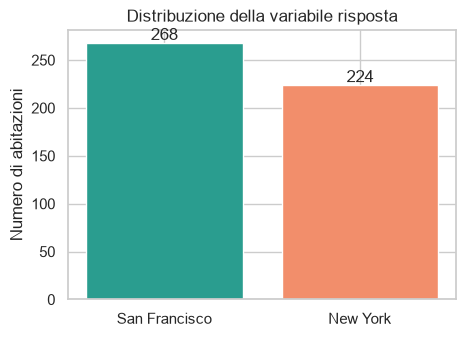

In [6]:
# Aggiungiamo un'etichetta testuale della città: più leggibile nei grafici e nelle tabelle
df["citta"] = df["in_sf"].map(ETICHETTE)

conteggi = df["citta"].value_counts()
percentuali = df["citta"].value_counts(normalize=True) * 100
display(pd.DataFrame({"n_abitazioni": conteggi, "percentuale": percentuali.round(1)}))

# Grafico a barre della distribuzione delle classi (fatto con matplotlib, cge ha una sintassi di costruzione progressiva dei grafici, aka plot)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(conteggi.index, conteggi.values, color=[COLORI[c] for c in conteggi.index])
for i, v in enumerate(conteggi.values):
    ax.text(i, v + 3, str(v), ha="center")
ax.set_ylabel("Numero di abitazioni")
ax.set_title("Distribuzione della variabile risposta")
plt.show()              # rendering

In [7]:
df.head()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation,citta
0,0,2.0,1.0,999000,1960,1000,999,10,New York
1,0,2.0,2.0,2750000,2006,1418,1939,0,New York
2,0,2.0,2.0,1350000,1900,2150,628,9,New York
3,0,1.0,1.0,629000,1903,500,1258,9,New York
4,0,0.0,1.0,439000,1930,500,878,10,New York


Le classi sono ragionevolmente bilanciate (circa 54% San Francisco, 46% New York), quindi l'accuratezza è una metrica adeguata. Teniamo a mente il valore di riferimento (**baseline**): un classificatore banale che risponde sempre "San Francisco" avrebbe un'accuratezza del 54,5%. Qualsiasi modello utile deve superare nettamente questa soglia.

### 2.2 Confronto delle variabili fra le due città

Calcoliamo media e mediana di ogni variabile per città: la mediana è più robusta della media in presenza di valori estremi.

In [8]:
# lista python delle colonne predittore (aka, feature)
FEATURES = ["beds", "bath", "price", "year_built", "sqft", "price_per_sqft", "elevation"]   #ovviamente qui non c'è la variabile risposta "citta" (o "in_sf")

# Media e mediana di ogni variabile, separatamente per città
with pd.option_context("display.float_format", "{:,.1f}".format):
    display(df.groupby("citta")[FEATURES].agg(["mean", "median"]).T)

citta                    New York  San Francisco
beds           mean           1.7            2.5
               median         2.0            2.0
bath           mean           1.8            2.0
               median         2.0            2.0
price          mean   2,787,579.4    1,379,718.9
               median 1,562,500.0      989,000.0
year_built     mean       1,965.1        1,954.1
               median     1,969.0        1,948.0
sqft           mean       1,398.0        1,627.4
               median     1,050.0        1,450.0
price_per_sqft mean       1,626.5          835.5
               median     1,416.0          768.5
elevation      mean          13.5           61.9
               median        10.0           55.0

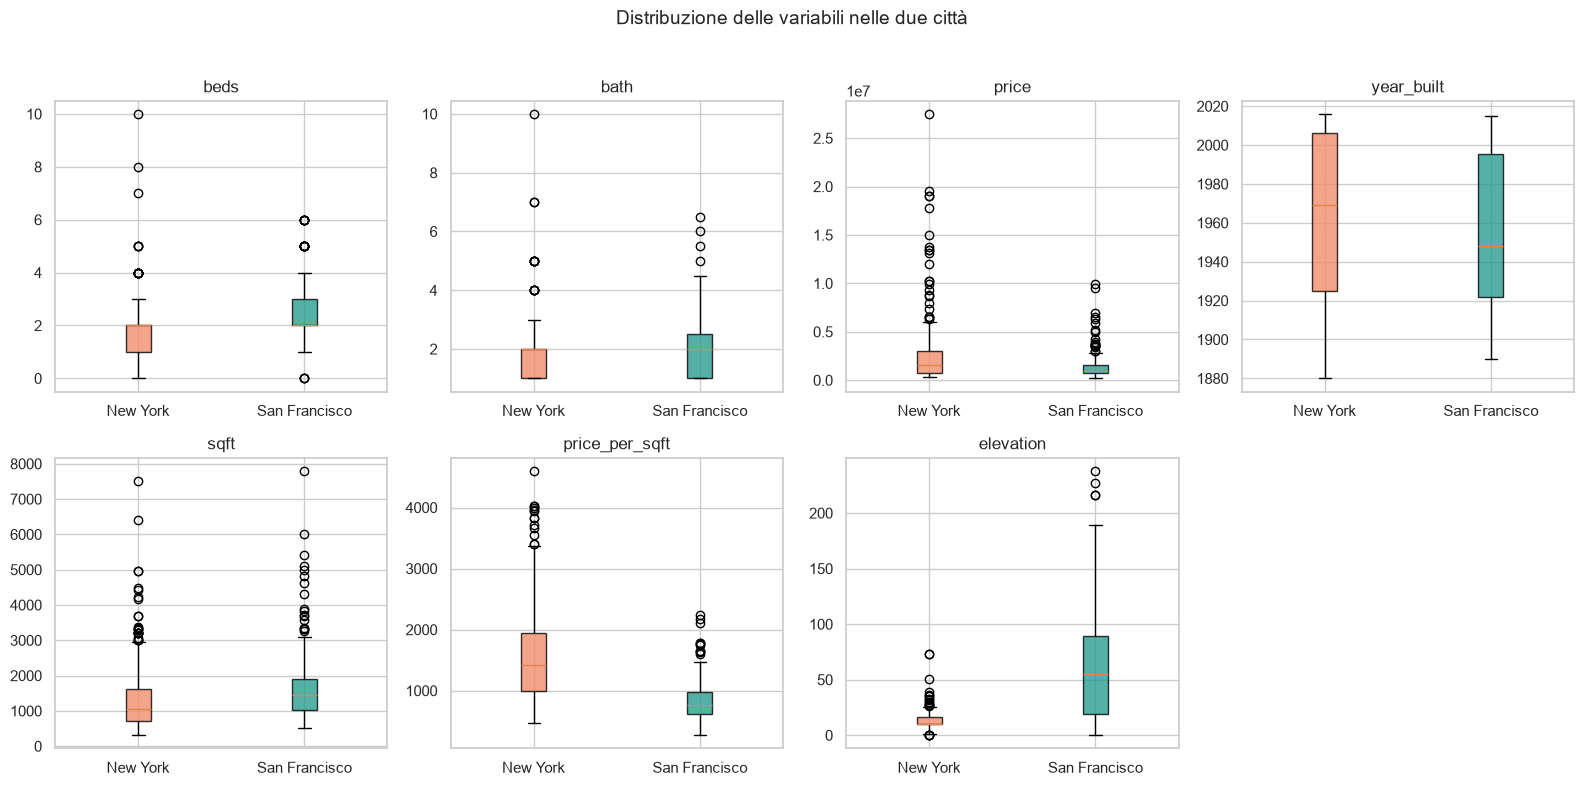

In [9]:
# Boxplot di ogni variabile per città: evidenziano differenze di mediana, dispersione e valori anomali
CITTA = ["New York", "San Francisco"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), FEATURES):
    dati = [df.loc[df["citta"] == c, col] for c in CITTA]
    bp = ax.boxplot(dati, patch_artist=True)
    for box, c in zip(bp["boxes"], CITTA):
        box.set_facecolor(COLORI[c])
        box.set_alpha(0.8)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(CITTA)
    ax.set_title(col)
axes.ravel()[-1].axis("off")   # l'ottavo riquadro resta vuoto
fig.suptitle("Distribuzione delle variabili nelle due città", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])   # lasciamo spazio al titolo generale
plt.show()

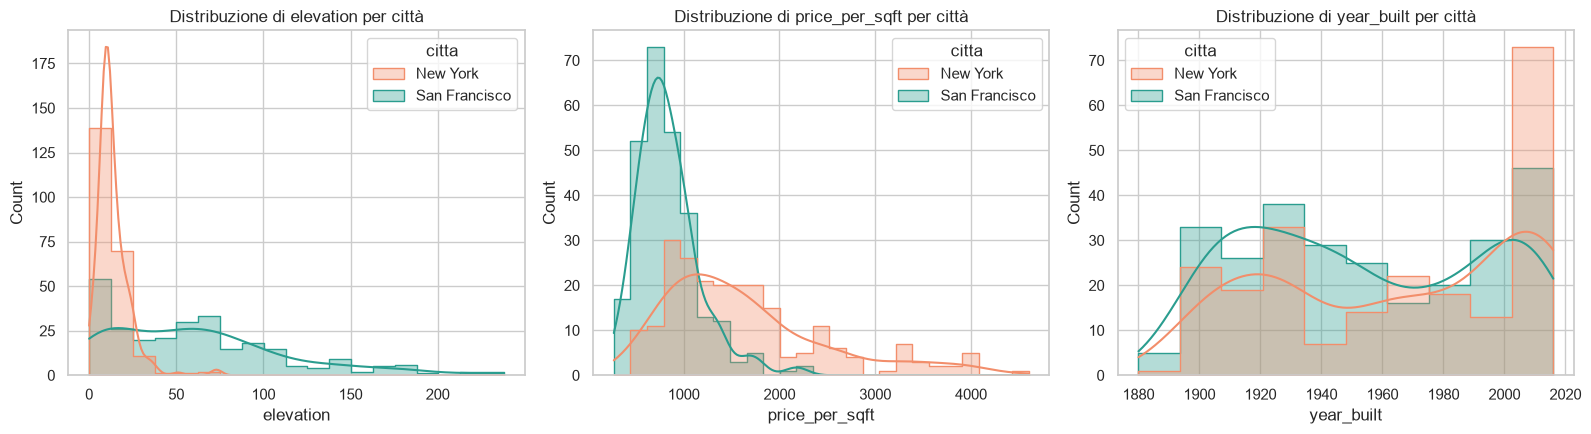

In [10]:
# Istogrammi sovrapposti (con stima di densità) per le tre variabili che sembrano più discriminanti
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["elevation", "price_per_sqft", "year_built"]):
    sns.histplot(data=df, x=col, hue="citta", palette=COLORI, kde=True, element="step", alpha=0.35, ax=ax)
    ax.set_title(f"Distribuzione di {col} per città")
plt.tight_layout()
plt.show()

**Cosa emerge dal confronto**

- **`elevation`** è la variabile più discriminante: San Francisco è una città collinare (mediana 55 m), mentre oltre l'80% delle abitazioni di New York sta sotto i 20 m e nessuna supera i 73 m.
- **`price_per_sqft`**: a New York il prezzo al piede quadrato è quasi il doppio (mediana ≈ 1.400 $ contro ≈ 770 $).
- **`year_built`**: le case di San Francisco sono mediamente più vecchie (mediana 1948 contro 1969).
- `beds` e `sqft` sono leggermente più alti a San Francisco; `bath` e `price` distinguono poco le due città (anche se il prezzo *medio* di New York è più alto, trascinato dalle abitazioni di lusso).

### 2.3 Relazioni fra le variabili

Guardiamo le variabili a coppie: il diagramma di dispersione fra altitudine e prezzo al piede quadrato è particolarmente eloquente.

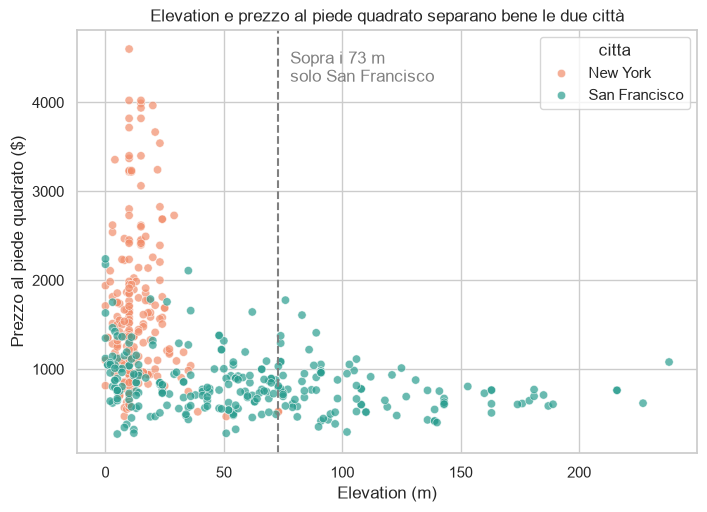

Abitazioni con elevation superiore a 73 m, per città:
citta
San Francisco    93
Name: count, dtype: int64


In [11]:
# Diagramma di dispersione (scatterplot) delle due variabili più informative (scoperto tramite analisi dei risultati)
# Fatto con seaborn, che ha una sintassi più compatta e orientata ai dati (aka grammar of graphics)
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=df, x="elevation", y="price_per_sqft", hue="citta", palette=COLORI, alpha=0.7, ax=ax)
ax.axvline(73, color="gray", linestyle="--")
ax.text(78, df["price_per_sqft"].max() * 0.92, "Sopra i 73 m\nsolo San Francisco", color="gray")
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Prezzo al piede quadrato ($)")
ax.set_title("Elevation e prezzo al piede quadrato separano bene le due città")
plt.show()

print("Abitazioni con elevation superiore a 73 m, per città:")
print(df.loc[df["elevation"] > 73, "citta"].value_counts())

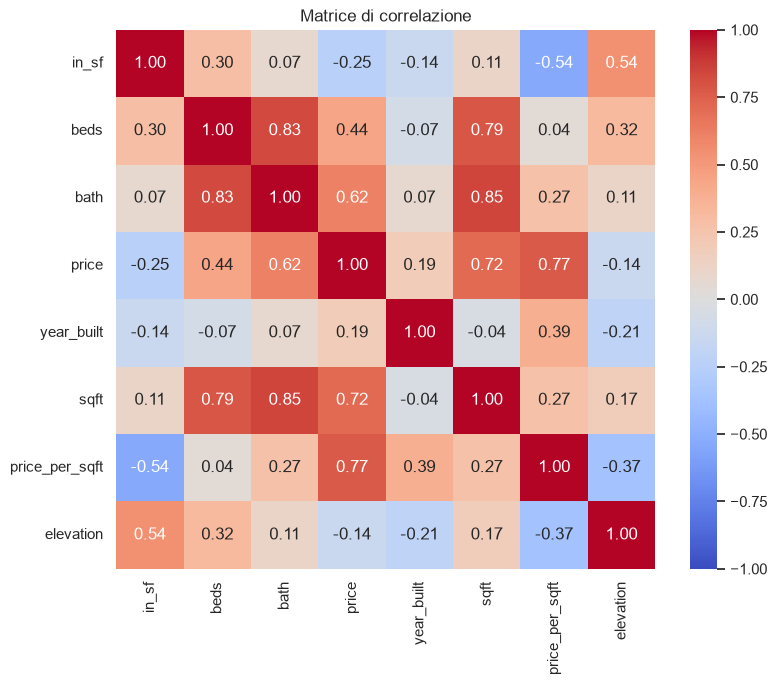

Correlazione di ogni variabile con la risposta in_sf (ordinata per valore assoluto):
elevation         0.540
price_per_sqft   -0.537
beds              0.295
price            -0.249
year_built       -0.136
sqft              0.113
bath              0.074
Name: in_sf, dtype: float64


In [12]:
# Matrice di correlazione (Pearson) fra tutte le variabili numeriche, compresa la risposta
corr = df[["in_sf"] + FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Matrice di correlazione")
plt.show()

print("Correlazione di ogni variabile con la risposta in_sf (ordinata per valore assoluto):")
print(corr["in_sf"].drop("in_sf").sort_values(key=abs, ascending=False).round(3))

Esaminiamo ora la [**scatterplot matrix**](https://seaborn.pydata.org/examples/scatterplot_matrix.html):

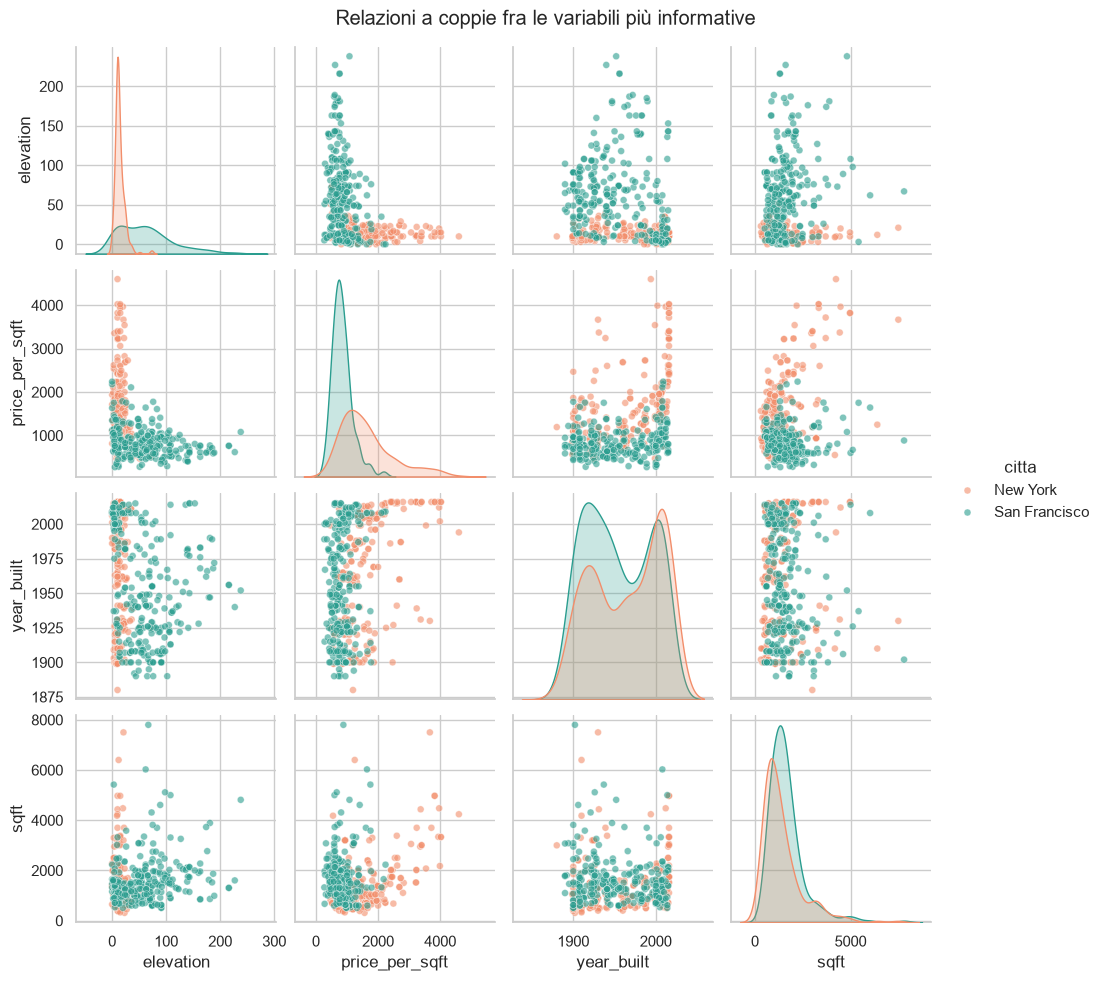

In [13]:
# Pairplot su un sottoinsieme di variabili: relazioni a coppie e separazione fra le classi
sns.pairplot(
    df, vars=["elevation", "price_per_sqft", "year_built", "sqft"], hue="citta",
    palette=COLORI, diag_kind="kde", plot_kws={"alpha": 0.6, "s": 25}, height=2.4,
)
plt.suptitle("Relazioni a coppie fra le variabili più informative", y=1.02)
plt.show()

**Sintesi dell'analisi esplorativa**

- Nessuna variabile da sola separa perfettamente le due città, ma `elevation` (correlazione +0,54 con `in_sf`) e `price_per_sqft` (−0,54) insieme ci vanno vicino: sopra i 73 m di altitudine troviamo **solo** abitazioni di San Francisco e, a parità di altitudine, le case di New York costano molto di più al piede quadrato.
- `price`, `sqft` e `price_per_sqft` sono legate fra loro per costruzione: questa **ridondanza** non disturba alberi e kNN, ma gonfia gli errori standard dei coefficienti della regressione logistica (ne riparleremo con statsmodels).
- Le classi non sono separabili con una soglia su una sola variabile: servono modelli che **combinino** più variabili, ed è esattamente quello che confrontiamo nelle prossime sezioni.

## 3. Preparazione dei dati e protocollo di valutazione

Definiamo con precisione **come** valuteremo i modelli, perché un protocollo sbagliato produce stime ottimistiche e non confrontabili.

**Suddivisione holdout (aka, test) con `train_test_split`.** Separiamo il 30% delle abitazioni in un **test set** che useremo una sola volta, alla fine, per misurare le prestazioni di ciascun modello. Lo split è **stratificato** (`stratify=y`): le proporzioni delle due città restano identiche in training e test.

**Cross-validazione sul training set.** Ogni modello ha degli iperparametri (profondità dell'albero, numero di vicini, architettura della rete, forza della regolarizzazione). Li scegliamo con `GridSearchCV`, cioè una **cross-validazione stratificata a 5 fold** eseguita esclusivamente sui dati di training: il test set non partecipa mai alla scelta. L'accuratezza media sui 5 fold è una prima stima onesta delle prestazioni.

**Standardizzazione dentro una `Pipeline`.** Per kNN, rete neurale e regressione logistica standardizziamo le variabili (media 0, deviazione standard 1). Mettendo `StandardScaler` dentro una `Pipeline`, lo scaler viene adattato solo sui dati di training di ciascun fold: evitiamo così il **data leakage**, cioè l'uso di informazioni del test set durante l'addestramento.

**Metriche.** Usiamo l'**accuratezza** (frazione di previsioni corrette) e la **matrice di confusione**, che nella convenzione di scikit-learn ha le classi vere sulle righe e quelle previste sulle colonne. La classe "positiva" è San Francisco (`in_sf = 1`):

| | Previsto New York | Previsto San Francisco |
|---|---|---|
| **Vero New York** | veri negativi (VN) | falsi positivi (FP) |
| **Vero San Francisco** | falsi negativi (FN) | veri positivi (VP) |

accuratezza = (VN + VP) / (VN + FP + FN + VP)

In [14]:
# Matrice delle variabili esplicative X e vettore della risposta y
X = df[FEATURES]
y = df["in_sf"]

# Suddivisione stratificata 70% / 30%: le proporzioni delle classi restano uguali nei due insiemi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} abitazioni  (quota San Francisco = {y_train.mean():.3f})")
print(f"Test set:     {X_test.shape[0]} abitazioni  (quota San Francisco = {y_test.mean():.3f})")

# Schema di cross-validazione usato per la scelta degli iperparametri di tutti i modelli
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Training set: 344 abitazioni  (quota San Francisco = 0.544)
Test set:     148 abitazioni  (quota San Francisco = 0.547)


In [15]:
# Dizionario in cui raccogliamo i risultati di ogni modello per il confronto finale
risultati = {}    # la inizializzazione del dizionario dei risultati va fatta prima di definire la funzione `valuta_modello`, altrimenti la funzione non può accedere a `risultati` (NameError).


def valuta_modello(nome, ricerca, X_test, y_test):
    """Valuta sul test set il miglior modello trovato da una GridSearchCV.

    Stampa gli iperparametri scelti, l'accuratezza di cross-validazione (sul training set)
    e l'accuratezza sul test set; disegna la matrice di confusione e salva tutto in `risultati`.
    """
    modello = ricerca.best_estimator_          # già riaddestrato su tutto il training set
    y_pred = modello.predict(X_test)

    acc_cv = ricerca.best_score_
    acc_test = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)      # righe = classe vera, colonne = classe prevista

    print(f"Modello: {nome}")
    print(f"  Iperparametri scelti:            {ricerca.best_params_}")
    print(f"  Accuratezza CV (5 fold, train):  {acc_cv:.4f}")
    print(f"  Accuratezza sul test set:        {acc_test:.4f}")
    print("  Matrice di confusione (righe = vero, colonne = previsto; ordine New York, San Francisco):")
    print(cm)

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["New York", "San Francisco"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"{nome}\naccuratezza test = {acc_test:.3f}")
    plt.show()

    risultati[nome] = {"modello": modello, "acc_cv": acc_cv, "acc_test": acc_test, "cm": cm}
    return modello

## 4. Modello 1 — Albero di decisione

Un albero di decisione partiziona lo spazio delle variabili con una sequenza di domande binarie (ad esempio `elevation <= 30.5?`), scelte a ogni passo per ridurre il più possibile l'**impurità** (indice di Gini) dei gruppi risultanti. È un modello facile da leggere e non richiede alcuna scalatura delle variabili.

Il rischio principale è l'**overfitting**: un albero lasciato crescere senza limiti isola ogni singola osservazione e impara il rumore. Controlliamo la complessità con due iperparametri, scelti in cross-validazione:

- `max_depth`: profondità massima dell'albero;
- `min_samples_leaf`: numero minimo di osservazioni in ogni foglia.

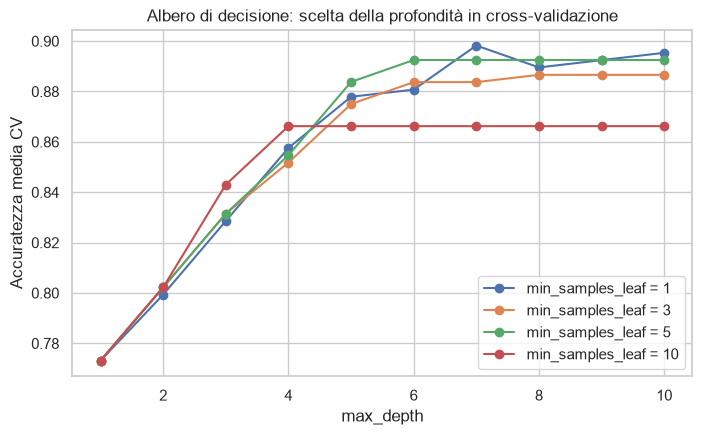

In [16]:
# Griglia di iperparametri: profondità massima e numero minimo di osservazioni per foglia
griglia_albero = {
    "max_depth": list(range(1, 11)),
    "min_samples_leaf": [1, 3, 5, 10],
}

ricerca_albero = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=griglia_albero,
    cv=cv,
    scoring="accuracy",
)
ricerca_albero.fit(X_train, y_train)      # l'albero lavora sulle variabili originali, senza scalatura

# Andamento dell'accuratezza CV al variare della profondità, per ciascun valore di min_samples_leaf
cv_res = pd.DataFrame(ricerca_albero.cv_results_)
fig, ax = plt.subplots(figsize=(8, 4.5))
for msl, gruppo in cv_res.groupby("param_min_samples_leaf"):
    ax.plot(gruppo["param_max_depth"].astype(int), gruppo["mean_test_score"], marker="o",
            label=f"min_samples_leaf = {msl}")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuratezza media CV")
ax.set_title("Albero di decisione: scelta della profondità in cross-validazione")
ax.legend()
plt.show()

Modello: Albero di decisione
  Iperparametri scelti:            {'max_depth': 7, 'min_samples_leaf': 1}
  Accuratezza CV (5 fold, train):  0.8983
  Accuratezza sul test set:        0.8919
  Matrice di confusione (righe = vero, colonne = previsto; ordine New York, San Francisco):
[[58  9]
 [ 7 74]]


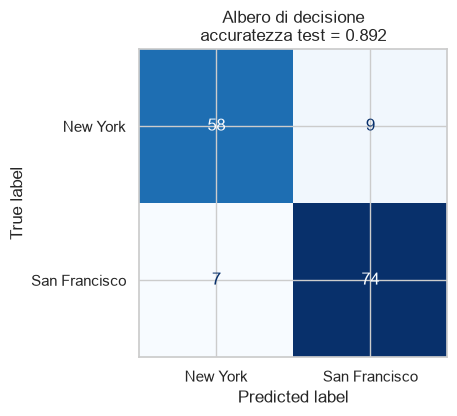


Profondità effettiva dell'albero: 7, numero di foglie: 32


In [17]:
albero = valuta_modello("Albero di decisione", ricerca_albero, X_test, y_test)
print(f"\nProfondità effettiva dell'albero: {albero.get_depth()}, numero di foglie: {albero.get_n_leaves()}")

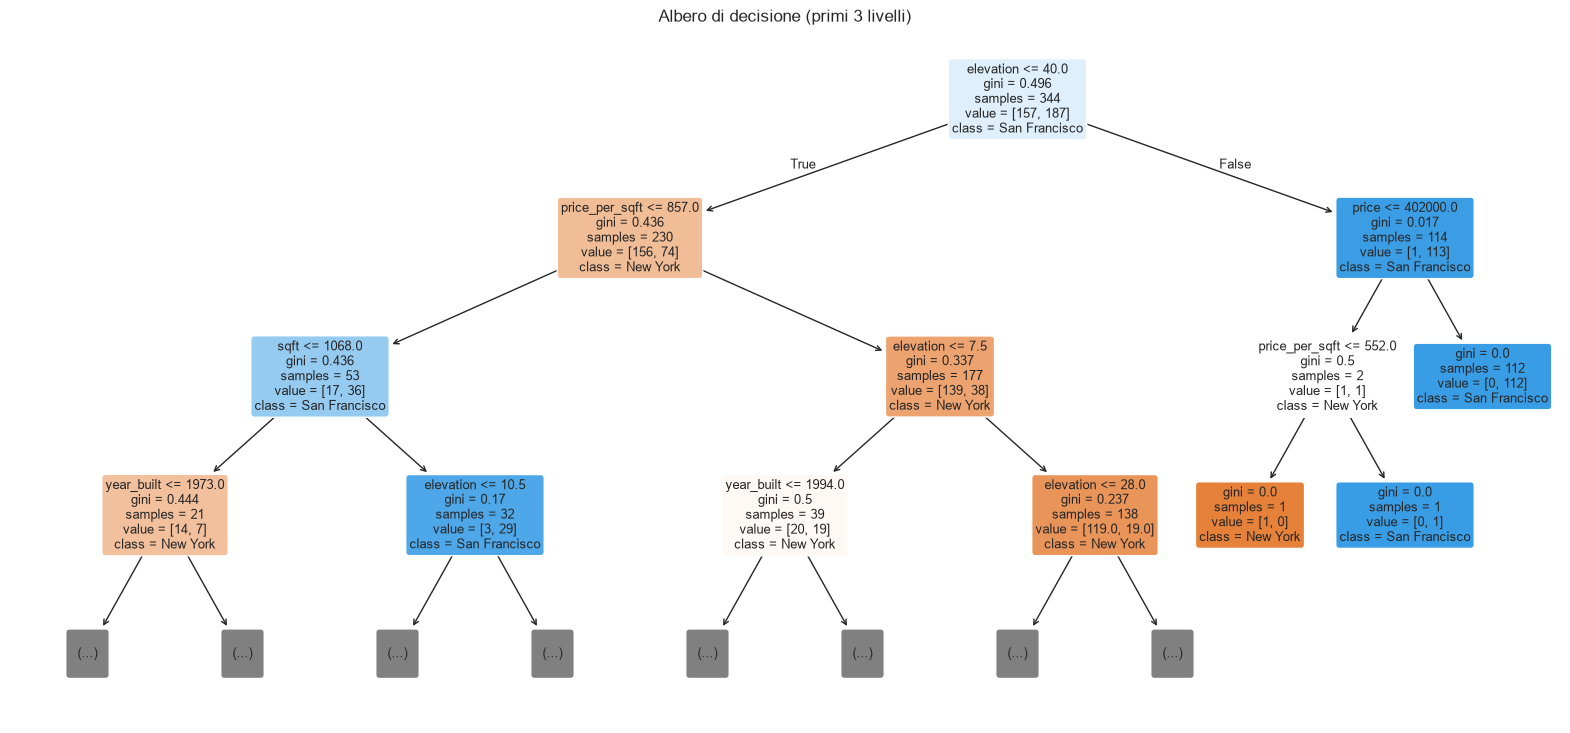

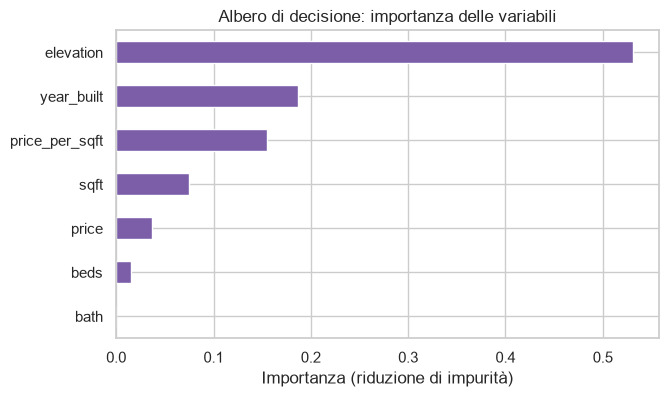

In [18]:
# Visualizziamo i primi livelli dell'albero: le prime domande sono le più informative
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    albero, max_depth=3, feature_names=FEATURES, class_names=["New York", "San Francisco"],
    filled=True, rounded=True, fontsize=9, ax=ax,
)
ax.set_title("Albero di decisione (primi 3 livelli)")
plt.show()

# Importanza delle variabili: quanto ciascuna contribuisce alla riduzione dell'impurità
importanze = pd.Series(albero.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importanze.plot.barh(ax=ax, color="#7B5EA7")
ax.set_xlabel("Importanza (riduzione di impurità)")
ax.set_title("Albero di decisione: importanza delle variabili")
plt.show()

**Lettura dei risultati**

- La radice dell'albero chiede se `elevation` supera i 40 m e subito sotto compare `price_per_sqft`, coerentemente con quanto visto nell'EDA. Nella classifica delle importanze `elevation` pesa da sola più della metà, seguita da `year_built` e `price_per_sqft`; `bath` non viene mai usata.
- La curva di cross-validazione cresce rapidamente fino a profondità 5-6 e poi si appiattisce: la griglia sceglie profondità 7 con foglie anche di una sola osservazione, ma da profondità 5 in poi le differenze sono di uno o due punti, cioè dell'ordine dell'errore di stima. In un contesto in cui conta l'interpretabilità potremmo preferire l'albero più semplice fra quelli "quasi equivalenti" (la cosiddetta *regola dell'errore standard*).

## 5. Modello 2 — k-Nearest Neighbors (kNN)

Il kNN non "impara" una funzione: per classificare una nuova abitazione cerca le **k abitazioni più vicine** nel training set (distanza euclidea) e assegna la classe più votata. Due conseguenze pratiche:

- la distanza è dominata dalle variabili con scala più grande (`price` vale milioni, `beds` poche unità): la **standardizzazione è indispensabile** e la inseriamo nella pipeline;
- `k` governa il compromesso fra flessibilità e stabilità: `k` piccolo segue anche il rumore, `k` grande produce confini più lisci ma meno precisi.

Proviamo anche `weights="distance"`, che pesa i vicini in modo inversamente proporzionale alla loro distanza.

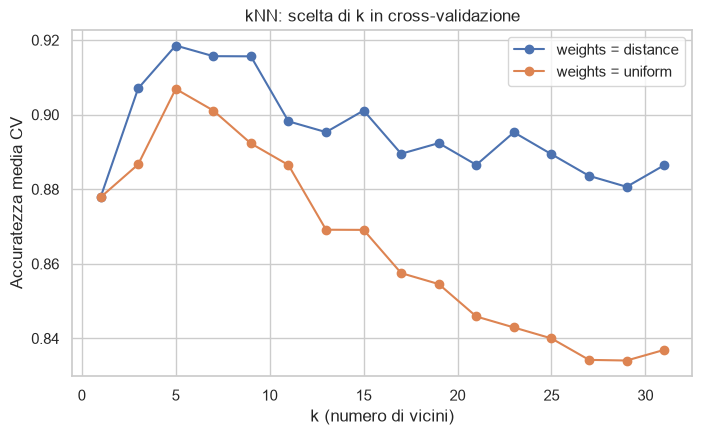

In [19]:
# Pipeline: standardizzazione (adattata solo sui dati di training di ogni fold) seguita dal kNN
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])

griglia_knn = {
    "knn__n_neighbors": list(range(1, 32, 2)),     # solo valori dispari: evitiamo i pareggi nel voto
    "knn__weights": ["uniform", "distance"],
}

ricerca_knn = GridSearchCV(pipe_knn, param_grid=griglia_knn, cv=cv, scoring="accuracy")
ricerca_knn.fit(X_train, y_train)

# Accuratezza CV al variare di k, per i due schemi di peso
cv_res = pd.DataFrame(ricerca_knn.cv_results_)
fig, ax = plt.subplots(figsize=(8, 4.5))
for w, gruppo in cv_res.groupby("param_knn__weights"):
    ax.plot(gruppo["param_knn__n_neighbors"].astype(int), gruppo["mean_test_score"], marker="o",
            label=f"weights = {w}")
ax.set_xlabel("k (numero di vicini)")
ax.set_ylabel("Accuratezza media CV")
ax.set_title("kNN: scelta di k in cross-validazione")
ax.legend()
plt.show()

Modello: kNN
  Iperparametri scelti:            {'knn__n_neighbors': 5, 'knn__weights': 'distance'}
  Accuratezza CV (5 fold, train):  0.9185
  Accuratezza sul test set:        0.9257
  Matrice di confusione (righe = vero, colonne = previsto; ordine New York, San Francisco):
[[63  4]
 [ 7 74]]


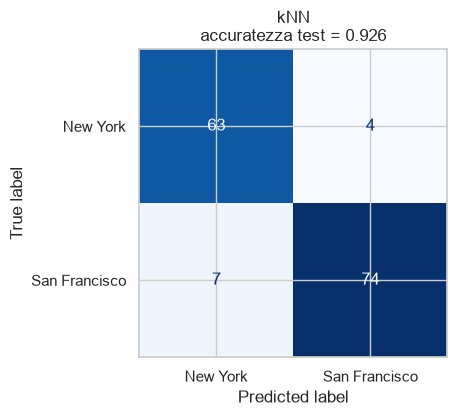

In [20]:
knn = valuta_modello("kNN", ricerca_knn, X_test, y_test)

In [21]:
# Quanto conta la standardizzazione? Confrontiamo in cross-validazione lo stesso kNN con e senza scaler
k_migliore = ricerca_knn.best_params_["knn__n_neighbors"]
pesi_migliori = ricerca_knn.best_params_["knn__weights"]
knn_senza_scaler = KNeighborsClassifier(n_neighbors=k_migliore, weights=pesi_migliori)
knn_con_scaler = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k_migliore, weights=pesi_migliori)),
])

acc_senza = cross_val_score(knn_senza_scaler, X_train, y_train, cv=cv, scoring="accuracy").mean()
acc_con = cross_val_score(knn_con_scaler, X_train, y_train, cv=cv, scoring="accuracy").mean()
print(f"Accuratezza CV del kNN (k = {k_migliore}) SENZA standardizzazione: {acc_senza:.4f}")
print(f"Accuratezza CV del kNN (k = {k_migliore}) CON standardizzazione:   {acc_con:.4f}")

Accuratezza CV del kNN (k = 5) SENZA standardizzazione: 0.6801
Accuratezza CV del kNN (k = 5) CON standardizzazione:   0.9185


**Lettura dei risultati**

- Il kNN standardizzato è fra i modelli migliori: con pochi vicini pesati per distanza il confine di decisione segue bene la forma "a due blocchi" vista nel diagramma altitudine / prezzo al piede quadrato.
- Senza standardizzazione, a parità di `k` e di pesi, l'accuratezza perde più di 20 punti: le distanze sono calcolate quasi solo su `price` (milioni di dollari), che è una delle variabili meno informative. È l'esempio più chiaro del perché il pre-processing va sempre inserito nella pipeline dei modelli basati su distanze.

## 6. Modello 3 — Rete neurale (Multi-Layer Perceptron)

`MLPClassifier` è una rete neurale *feed-forward*: le variabili in ingresso attraversano uno o più **strati nascosti** di neuroni con attivazione ReLU, e il neurone di uscita (attivazione logistica) restituisce la probabilità di San Francisco. I pesi vengono stimati minimizzando la log-loss con l'ottimizzatore Adam.

Anche qui la standardizzazione è necessaria (l'addestramento è basato sul gradiente). Con poche centinaia di osservazioni conviene usare reti **piccole** e regolarizzate: esploriamo in cross-validazione alcune architetture e il parametro `alpha` (penalità L2 sui pesi). Questa ricerca richiede circa 30 secondi.

In [ ]:
# circa 30"
pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=2000, random_state=RANDOM_STATE)),
])

griglia_mlp = {
    "mlp__hidden_layer_sizes": [(8,), (16,), (16, 8), (32, 16)],   # architetture con 1 o 2 strati nascosti
    "mlp__alpha": [1e-4, 1e-2, 1e-1, 1.0],                          # forza della regolarizzazione L2
}

ricerca_mlp = GridSearchCV(pipe_mlp, param_grid=griglia_mlp, cv=cv, scoring="accuracy")
ricerca_mlp.fit(X_train, y_train)      # 16 configurazioni x 5 fold

# Tabella riassuntiva: accuratezza CV per architettura (righe) e alpha (colonne)
cv_res = pd.DataFrame(ricerca_mlp.cv_results_)
cv_res["architettura"] = cv_res["param_mlp__hidden_layer_sizes"].astype(str)
cv_res["alpha"] = cv_res["param_mlp__alpha"].astype(str)
cv_res.pivot(index="architettura", columns="alpha", values="mean_test_score").round(4)

alpha,0.0001,0.01,0.1,1.0
architettura,,,,
"(16, 8)",0.898,0.901,0.901,0.892
"(16,)",0.878,0.884,0.889,0.881
"(32, 16)",0.887,0.884,0.883,0.886
"(8,)",0.866,0.866,0.866,0.875


Modello: Rete neurale (MLP)
  Iperparametri scelti:            {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (16, 8)}
  Accuratezza CV (5 fold, train):  0.9010
  Accuratezza sul test set:        0.9122
  Matrice di confusione (righe = vero, colonne = previsto; ordine New York, San Francisco):
[[61  6]
 [ 7 74]]


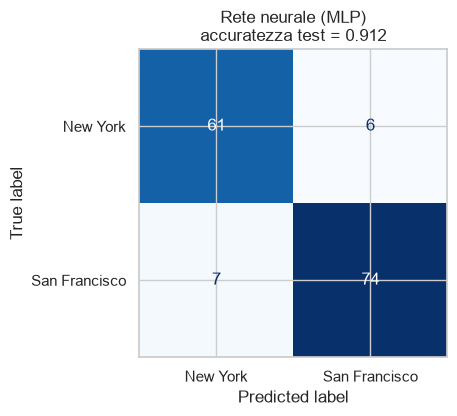


Iterazioni (epoche) eseguite prima della convergenza: 571


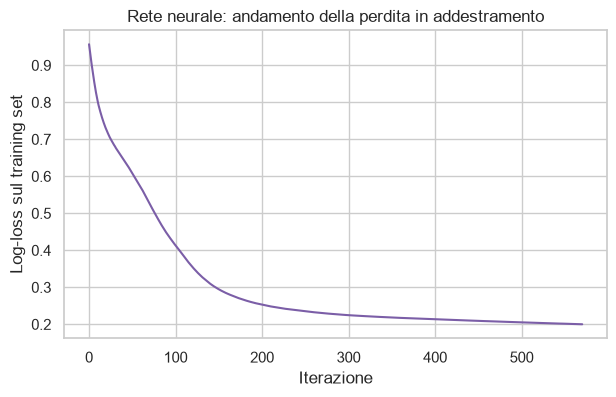

In [23]:
mlp = valuta_modello("Rete neurale (MLP)", ricerca_mlp, X_test, y_test)

# Curva della funzione di perdita durante l'addestramento del modello finale
rete = mlp.named_steps["mlp"]
print(f"\nIterazioni (epoche) eseguite prima della convergenza: {rete.n_iter_}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rete.loss_curve_, color="#7B5EA7")
ax.set_xlabel("Iterazione")
ax.set_ylabel("Log-loss sul training set")
ax.set_title("Rete neurale: andamento della perdita in addestramento")
plt.show()

**Lettura dei risultati**

- La rete raggiunge un'accuratezza in linea con kNN e regressione logistica: su dati tabellari piccoli e con poche variabili una rete neurale **non ha un vantaggio sistematico** rispetto a modelli più semplici, e costa di più in tempo di calcolo e in numero di scelte da fare (architettura, regolarizzazione, ottimizzatore).
- La curva della perdita decresce e si stabilizza: l'addestramento è arrivato a convergenza. La tabella della griglia mostra che configurazioni diverse danno risultati molto vicini fra loro, segno che la regolarizzazione `alpha` tiene sotto controllo l'overfitting.

## 7. Modello 4 — Regressione logistica

### 7.1 Stima predittiva con scikit-learn

La regressione logistica modella la probabilità di San Francisco come funzione lineare delle variabili, passata attraverso la funzione logistica:

$$P(\text{SF} \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_7 x_7)}}$$

Equivalentemente, il **logaritmo degli odds** $\log \frac{P}{1-P}$ è lineare nelle variabili. Con le variabili standardizzate ogni coefficiente $\beta_j$ misura la variazione del log-odds per un aumento di **una deviazione standard** di $x_j$, quindi i coefficienti sono direttamente confrontabili fra loro.

`LogisticRegression` di scikit-learn applica per default una penalità L2 governata da `C` (più `C` è grande, più debole è la regolarizzazione): scegliamo `C` in cross-validazione.

In [24]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000)),
])

griglia_lr = {"lr__C": [0.01, 0.1, 1, 10, 100]}      # C grande = poca regolarizzazione

ricerca_lr = GridSearchCV(pipe_lr, param_grid=griglia_lr, cv=cv, scoring="accuracy")
ricerca_lr.fit(X_train, y_train)

pd.DataFrame(ricerca_lr.cv_results_)[["param_lr__C", "mean_test_score", "std_test_score"]].round(4)

,param_lr__C,mean_test_score,std_test_score
0,0.01,0.808,0.032
1,0.10,0.872,0.030
2,1.00,0.884,0.021
3,10.00,0.889,0.020
4,100.00,0.892,0.018


Modello: Regressione logistica
  Iperparametri scelti:            {'lr__C': 100}
  Accuratezza CV (5 fold, train):  0.8924
  Accuratezza sul test set:        0.9189
  Matrice di confusione (righe = vero, colonne = previsto; ordine New York, San Francisco):
[[62  5]
 [ 7 74]]


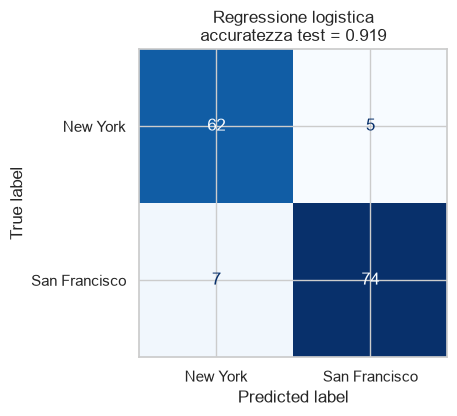


Intercetta: 1.511


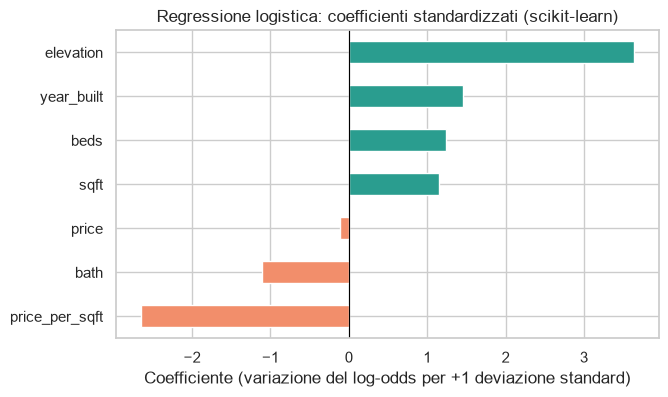

In [25]:
logistica = valuta_modello("Regressione logistica", ricerca_lr, X_test, y_test)

# Coefficienti stimati sulle variabili standardizzate: segno e grandezza relativa
coef_sklearn = pd.Series(logistica.named_steps["lr"].coef_[0], index=FEATURES)
print(f"\nIntercetta: {logistica.named_steps['lr'].intercept_[0]:.3f}")

coef_ordinati = coef_sklearn.sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
coef_ordinati.plot.barh(ax=ax, color=["#2A9D8F" if c > 0 else "#F28E6B" for c in coef_ordinati])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficiente (variazione del log-odds per +1 deviazione standard)")
ax.set_title("Regressione logistica: coefficienti standardizzati (scikit-learn)")
plt.show()

**Lettura dei coefficienti**

- Un coefficiente positivo aumenta la probabilità di San Francisco, uno negativo la riduce. `elevation` (positivo) e `price_per_sqft` (negativo) sono di gran lunga i più influenti, come suggeriva l'EDA.
- `year_built` ha coefficiente **positivo**, anche se nell'EDA le case di San Francisco risultavano mediamente più vecchie. Non è una contraddizione: il coefficiente misura l'effetto *a parità delle altre variabili* (effetto **condizionato**), mentre il confronto delle mediane misura l'effetto **marginale**. A parità di altitudine, prezzo al piede quadrato e dimensioni, una casa più recente è più probabilmente a San Francisco.
- La cross-validazione sceglie un valore di `C` alto: con 344 osservazioni e 7 variabili la regolarizzazione serve poco, e i coefficienti sono quasi identici alla stima di massima verosimiglianza che otterremo con statsmodels.

### 7.2 Inferenza sui parametri con statsmodels

scikit-learn è orientato alla previsione e non calcola errori standard né p-value. Per l'**inferenza** sui parametri usiamo `statsmodels`, che stima la regressione logistica per **massima verosimiglianza** (senza penalità) e fornisce:

- l'errore standard di ogni coefficiente e il test di Wald ($z$ e p-value) per l'ipotesi $H_0: \beta_j = 0$;
- gli intervalli di confidenza al 95%;
- il test del rapporto di verosimiglianza (LLR) contro il modello con la sola intercetta e lo pseudo-$R^2$ di McFadden.

Usiamo le stesse variabili standardizzate (con lo scaler adattato sul training set), così i coefficienti sono confrontabili con quelli di scikit-learn. A differenza di scikit-learn, statsmodels **non aggiunge l'intercetta automaticamente**: la inseriamo con `add_constant`.

In [26]:
import statsmodels.api as sm

# Standardizziamo con lo scaler già adattato sul training set (stessa trasformazione usata da scikit-learn)
scaler_lr = logistica.named_steps["scaler"]
X_train_std = pd.DataFrame(scaler_lr.transform(X_train), columns=FEATURES, index=X_train.index)

# statsmodels non inserisce l'intercetta da solo: aggiungiamo una colonna costante
X_train_sm = sm.add_constant(X_train_std)

# Stima di massima verosimiglianza (nessuna regolarizzazione)
logit_sm = sm.Logit(y_train, X_train_sm).fit(disp=0)
print(logit_sm.summary())

                           Logit Regression Results                           
Dep. Variable:                  in_sf   No. Observations:                  344
Model:                          Logit   Df Residuals:                      336
Method:                           MLE   Df Model:                            7
Date:                ven, 11 set 2026   Pseudo R-squ.:                  0.5818
Time:                        18:58:18   Log-Likelihood:                -99.168
converged:                       True   LL-Null:                       -237.13
Covariance Type:            nonrobust   LLR p-value:                 8.283e-56
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.5194      0.354      4.297      0.000       0.826       2.212
beds               1.2412      0.445      2.791      0.005       0.370       2.113
bath              -1.1097      0.477

**Come leggere la tabella**

- `coef`: stima del coefficiente (variazione del log-odds per +1 deviazione standard); `std err`: errore standard;
- `z` e `P>|z|`: statistica e p-value del test di Wald ($H_0: \beta_j = 0$); un p-value sotto 0,05 indica un effetto significativo *a parità delle altre variabili*;
- `[0.025  0.975]`: intervallo di confidenza al 95% del coefficiente;
- `LLR p-value`: il modello completo spiega significativamente più del modello nullo (sola intercetta); `Pseudo R-squ.`: quota di log-verosimiglianza "recuperata" rispetto al modello nullo.

Poiché il coefficiente agisce sul log-odds, $e^{\beta_j}$ è l'**odds ratio**: il fattore per cui si moltiplicano gli odds di San Francisco quando la variabile aumenta di una deviazione standard. Costruiamo una tabella riassuntiva con coefficienti, intervalli di confidenza e odds ratio.

In [27]:
# Tabella riassuntiva: coefficienti, intervalli di confidenza al 95% e odds ratio
ic = logit_sm.conf_int(alpha=0.05)
inferenza = pd.DataFrame({
    "coef": logit_sm.params,
    "std_err": logit_sm.bse,
    "z": logit_sm.tvalues,
    "p_value": logit_sm.pvalues,
    "IC95_inf": ic[0],
    "IC95_sup": ic[1],
})
inferenza["odds_ratio"] = np.exp(inferenza["coef"])
inferenza["OR_IC95_inf"] = np.exp(inferenza["IC95_inf"])
inferenza["OR_IC95_sup"] = np.exp(inferenza["IC95_sup"])
inferenza["significativa_5%"] = inferenza["p_value"] < 0.05
inferenza.round(4)

,coef,std_err,z,p_value,IC95_inf,IC95_sup,odds_ratio,OR_IC95_inf,OR_IC95_sup,significativa_5%
const,1.519,0.354,4.297,0.000,0.826,2.212,4.569,2.285,9.137,True
beds,1.241,0.445,2.791,0.005,0.370,2.113,3.460,1.447,8.271,True
bath,-1.110,0.477,-2.328,0.020,-2.044,-0.175,0.330,0.130,0.839,True
price,-0.104,1.170,-0.089,0.929,-2.397,2.189,0.901,0.091,8.931,False
year_built,1.459,0.268,5.451,0.000,0.935,1.984,4.303,2.546,7.272,True
sqft,1.154,0.730,1.581,0.114,-0.276,2.584,3.170,0.759,13.245,False
price_per_sqft,-2.664,0.621,-4.293,0.000,-3.881,-1.448,0.070,0.021,0.235,True
elevation,3.656,0.610,5.993,0.000,2.461,4.852,38.724,11.713,128.031,True


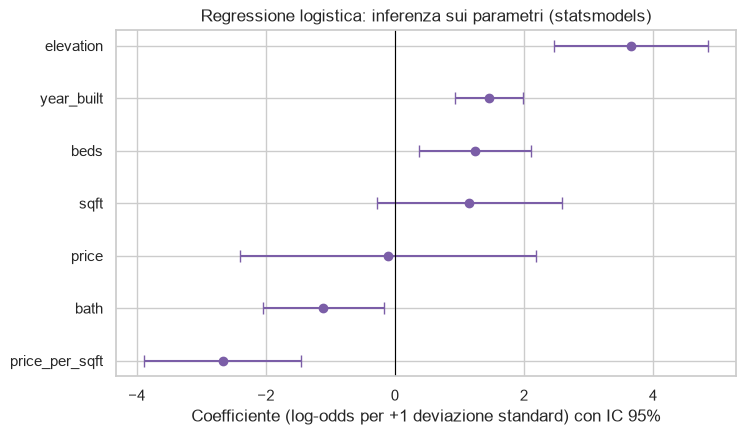

In [28]:
# Grafico dei coefficienti con intervalli di confidenza al 95% (intercetta esclusa)
senza_const = inferenza.drop(index="const").sort_values("coef")
errori = [senza_const["coef"] - senza_const["IC95_inf"], senza_const["IC95_sup"] - senza_const["coef"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(senza_const["coef"].values, list(senza_const.index), xerr=errori, fmt="o", color="#7B5EA7", capsize=4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficiente (log-odds per +1 deviazione standard) con IC 95%")
ax.set_title("Regressione logistica: inferenza sui parametri (statsmodels)")
plt.show()

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Fattori di inflazione della varianza: valori sopra 5-10 segnalano collinearità forte (errori standard gonfiati)
vif = pd.DataFrame({
    "variabile": FEATURES,
    "VIF": [variance_inflation_factor(X_train_sm.values, i) for i in range(1, X_train_sm.shape[1])],
})
vif.round(2)

,variabile,VIF
0,beds,4.63
1,bath,5.32
2,price,8.84
3,year_built,1.23
4,sqft,7.01
5,price_per_sqft,4.89
6,elevation,1.39


In [30]:
# Confronto fra i coefficienti di scikit-learn (lieve regolarizzazione L2) e di statsmodels (massima verosimiglianza)
confronto = pd.DataFrame({
    "scikit-learn": pd.concat([pd.Series({"const": logistica.named_steps["lr"].intercept_[0]}), coef_sklearn]),
    "statsmodels": logit_sm.params,
})
confronto["differenza"] = confronto["scikit-learn"] - confronto["statsmodels"]
confronto.round(4)

,scikit-learn,statsmodels,differenza
const,1.511,1.519,-0.009
beds,1.243,1.241,0.002
bath,-1.107,-1.110,0.003
price,-0.111,-0.104,-0.007
year_built,1.453,1.459,-0.006
sqft,1.149,1.154,-0.004
price_per_sqft,-2.654,-2.664,0.011
elevation,3.639,3.656,-0.018


**Lettura dell'inferenza**

- Il test LLR ha p-value praticamente nullo e lo pseudo-$R^2$ di McFadden vale circa 0,58: il modello spiega una quota molto rilevante della variabilità della risposta.
- `elevation`, `price_per_sqft` e `year_built` hanno p-value molto inferiori a 0,001: sono le variabili con evidenza più forte. L'odds ratio di `elevation` è enorme, circa 39 per deviazione standard (le abitazioni in collina sono quasi certamente a San Francisco); quello di `price_per_sqft` è molto inferiore a 1 (a parità del resto, un prezzo al piede quadrato più alto spinge verso New York).
- `beds` e `bath` sono significative al 5% ma con intervalli di confidenza ampi; `sqft` e `price` **non** sono significative: il loro contributo, al netto delle altre variabili, è in gran parte già catturato da `price_per_sqft`, che dipende da entrambe per costruzione.
- Il VIF conferma la ridondanza discussa nell'EDA: `price` (≈ 9) e `sqft` (≈ 7) hanno i valori più alti, seguiti da `bath` e `price_per_sqft` (≈ 5), mentre `elevation` e `year_built` sono praticamente indipendenti dalle altre. La collinearità non peggiora le previsioni, ma rende meno precise (intervalli più larghi) le stime dei singoli coefficienti coinvolti: è uno dei motivi per cui `price` e `sqft` non risultano significative.
- I coefficienti di scikit-learn e di statsmodels coincidono fino alla seconda cifra decimale: la penalità L2 con `C` alto è quasi ininfluente. La differenza fra le due librerie non sta nella stima, ma in ciò che ci restituiscono: scikit-learn una pipeline predittiva, statsmodels l'apparato inferenziale.

## 8. Confronto finale dei modelli

Raccogliamo le metriche dei quattro modelli: accuratezza di cross-validazione (calcolata sul training set durante la scelta degli iperparametri), accuratezza sul test set ed errori commessi per tipo.

In [31]:
righe = []
for nome, r in risultati.items():
    cm = r["cm"]
    righe.append({
        "Modello": nome,
        "Accuratezza CV (train)": round(r["acc_cv"], 4),
        "Accuratezza test": round(r["acc_test"], 4),
        "Errori sul test": int(cm.sum() - np.trace(cm)),
        "Falsi San Francisco (NY -> SF)": int(cm[0, 1]),
        "Falsi New York (SF -> NY)": int(cm[1, 0]),
    })
tabella = pd.DataFrame(righe).set_index("Modello").sort_values("Accuratezza test", ascending=False)
tabella

,Accuratezza CV (train),Accuratezza test,Errori sul test,Falsi San Francisco (NY -> SF),Falsi New York (SF -> NY)
Modello,,,,,
kNN,0.918,0.926,11,4,7
Regressione logistica,0.892,0.919,12,5,7
Rete neurale (MLP),0.901,0.912,13,6,7
Albero di decisione,0.898,0.892,16,9,7


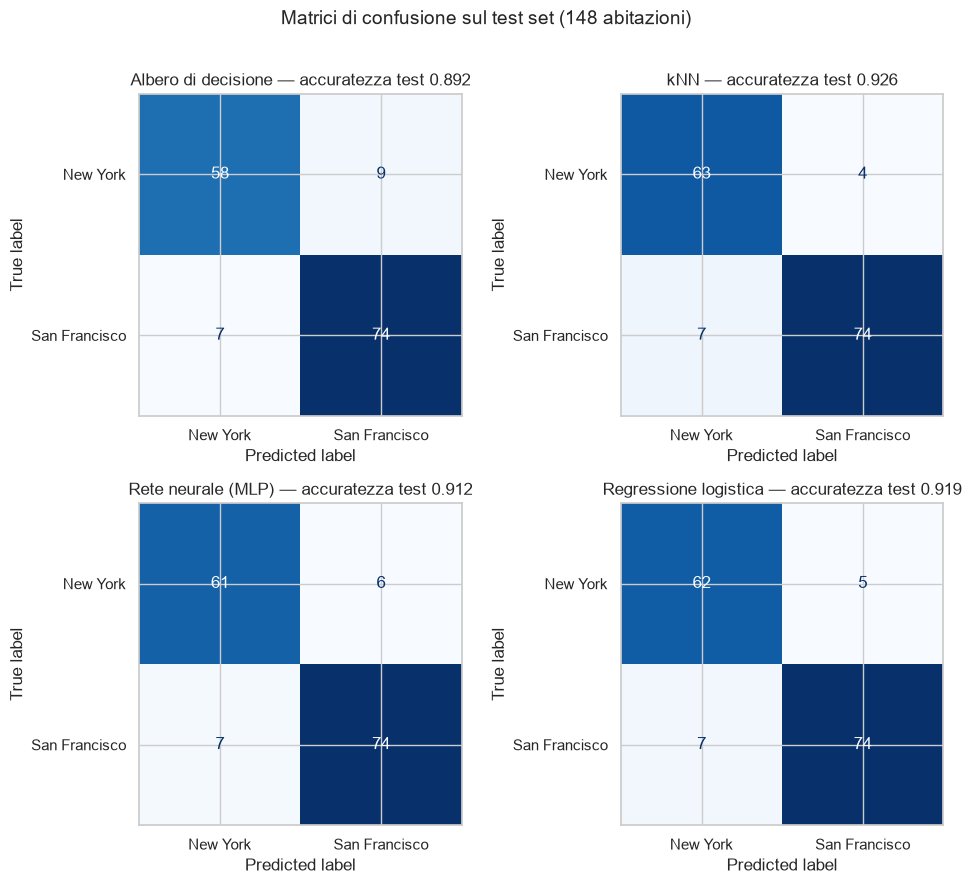

In [32]:
# Le quattro matrici di confusione affiancate
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (nome, r) in zip(axes.ravel(), risultati.items()):
    ConfusionMatrixDisplay(r["cm"], display_labels=["New York", "San Francisco"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"{nome} — accuratezza test {r['acc_test']:.3f}")
fig.suptitle(f"Matrici di confusione sul test set ({len(y_test)} abitazioni)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Il test set contiene 148 abitazioni: **ogni errore in più o in meno vale circa 0,7 punti di accuratezza**, quindi differenze di uno o due punti fra i modelli rientrano nell'incertezza di stima. Per un confronto più stabile ripetiamo la valutazione con una **cross-validazione a 10 fold sull'intero dataset**, usando per ogni modello gli iperparametri già scelti: otteniamo dieci misure di accuratezza per modello invece di una sola.

Nota metodologica: gli iperparametri sono stati scelti usando una parte di questi stessi dati, quindi la stima è leggermente ottimistica; la procedura rigorosa sarebbe una *nested cross-validation*, che ripete la scelta degli iperparametri dentro ogni fold.

In [ ]:
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# cross_val_score clona e riaddestra il modello su ogni fold: gli iperparametri restano quelli scelti
punteggi = pd.DataFrame({
    nome: cross_val_score(r["modello"], X, y, cv=cv10, scoring="accuracy") for nome, r in risultati.items()
})

print("Accuratezza media (± deviazione standard) su 10 fold:")
for nome in punteggi.columns:
    print(f"  {nome:<24s} {punteggi[nome].mean():.4f} ± {punteggi[nome].std():.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot([punteggi[c] for c in punteggi.columns], patch_artist=True,
           boxprops={"facecolor": "#B8A9D6"})
ax.set_xticks(range(1, len(punteggi.columns) + 1))
ax.set_xticklabels(punteggi.columns)
ax.set_ylabel("Accuratezza")
ax.set_title("Distribuzione dell'accuratezza su 10 fold (intero dataset)")
plt.show()

## 9. Conclusioni

- Tutti e quattro i modelli superano ampiamente la baseline del 54,5% e si collocano fra l'89% e il 93% di accuratezza sul test set, e la cross-validazione a 10 fold conferma il quadro: il **kNN** è il migliore in entrambe le valutazioni, regressione logistica e rete neurale sono praticamente alla pari, l'albero è leggermente indietro ed è il più variabile da un fold all'altro. La rete neurale non offre vantaggi che ne giustifichino il costo.
- Le matrici di confusione mostrano errori distribuiti in modo simile fra le due classi: nessun modello è sistematicamente sbilanciato verso una città.
- La scelta finale dipende dall'uso: se serve **interpretare** il fenomeno, la regressione logistica (coefficienti, odds ratio, p-value e intervalli di confidenza da statsmodels) e l'albero (regole leggibili) sono preferibili al kNN e alla rete, che restano modelli "a scatola nera".

**Possibili estensioni**

- Trasformare in logaritmo `price` e `sqft` per ridurre l'asimmetria, o costruire nuove variabili (ad esempio interazioni fra altitudine e prezzo).
- Affiancare all'accuratezza altre metriche: precisione, richiamo, F1, curva ROC e AUC, calibrazione delle probabilità.
- Stimare le prestazioni con una nested cross-validation e provare modelli di ensemble (random forest, gradient boosting), tipicamente forti su dati tabellari.